In [54]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

**Preprocessing**

In [55]:
file = pd.read_csv("../../Data/data_with_weather.csv")
file['datetime'] = pd.to_datetime(file['datetime'])
file['hour'] = file['datetime'].dt.hour+file['datetime'].dt.minute/60
file = file.sort_values('datetime').reset_index(drop=True)

**Finding good features**

In [56]:
file['demandH1'] = file['demand'].shift(1).fillna(0)
file['demandH2'] = file['demand'].shift(2).fillna(0)
file['demandH3'] = file['demand'].shift(3).fillna(0)
file['demand24H'] = file['demand'].shift(24).fillna(0)
file['demand48H'] = file['demand'].shift(48).fillna(0)
file['demand168H'] = file['demand'].shift(168).fillna(0)
file['roll_mean_24h'] = file['demand'].shift(1).rolling(24).mean().fillna(0)

file['hour_sin'] = np.sin(2*np.pi*file['hour']/24)
file['hour_cos'] = np.cos(2*np.pi*file['hour']/24)

file['minutes'] = file['datetime'].dt.hour*60+file['datetime'].dt.minute
file['hour^2'] = file['minutes']**2
file['hour^3'] = file['minutes']**3

file['demand24HAgo'] = file['demand'].shift(24).fillna(0)
file['demand7HAgo'] = file['demand'].shift(24*7).fillna(0)

hourOneHotEncoding = pd.get_dummies(file['hour'], prefix='h').astype(int)
file = pd.concat([file, hourOneHotEncoding], axis=1)
hour_columns = [col for col in file.columns if col.startswith('h_')]

for h in hour_columns:
    file[f'{h}_weekend'] = file[h]*file['is_weekend']

file['rush'] = ((file['hour'] == 7) & (file['is_weekend'] == 0)).astype(int)
cols = [col for col in file.columns if col.endswith('_weekend')]
# print(file.head()) # print the beginning of the file
# print(file.info()) # Print name of columns
weather_columns = [
    'temp', 
    'feelslike', 
    'precip',
    'snow', 
    'snowdepth', 
    'is_snowing', 
    'is_raining'
]

features = [
    'demand',
    'minutes', 
    'is_weekend', 
    'event', 
    'rush', 
    'demandH1', 
    'demandH2', 
    'demandH3',
    'hour_sin', 
    'hour_cos', 
    'demand24HAgo', 
    'demand7HAgo'
] + cols + hour_columns + weather_columns

file['rain_rush'] = file['is_raining'] * file['rush']
features.append('rain_rush')

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(file[features])
scaled_frame = pd.DataFrame(scaled_data, columns=scaler.get_feature_names_out())
file[features] = scaled_frame.values

**Dividing test and train data**

In [57]:
split_idx = int(len(file)*0.80)
trf = file.iloc[:split_idx]
tef = file.iloc[split_idx:]

x_train = trf[features]
x_test = tef[features]
y_train = trf['demand']
y_test = tef['demand']
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Running the model and metrics**

In [58]:
pred = model.predict(x_test)
y_pred = np.maximum(0, pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print()
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")
print(f"R^2 : {r2}")


RMSE : 1.6170005465969287e-15
MAE : 1.1869702655445156e-15
R^2 : 1.0


**Graph of metrics**

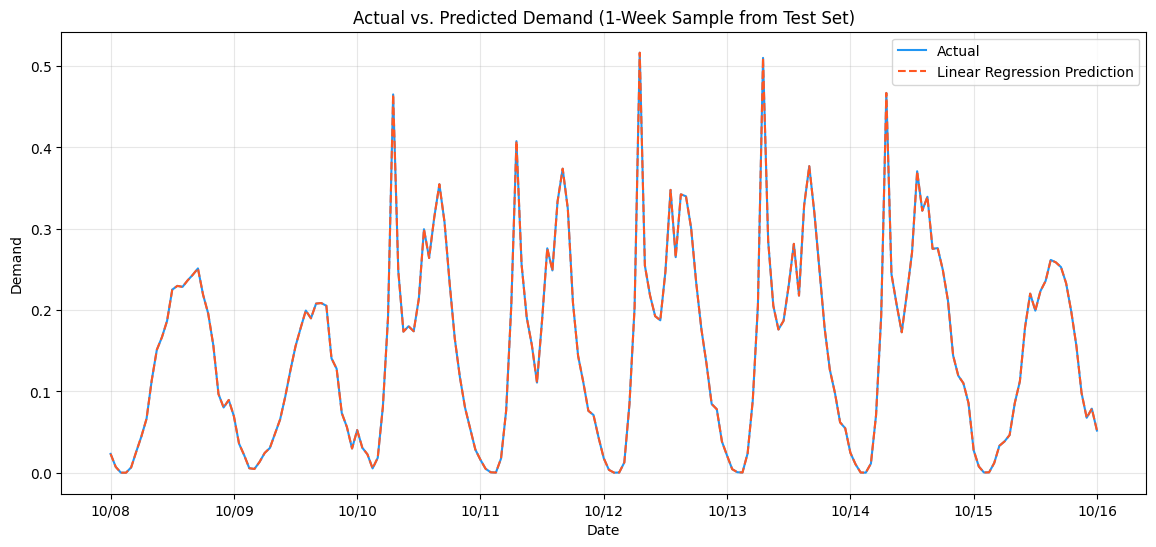

In [59]:
mask = (tef['datetime'] >= '2022-10-08') & (tef['datetime'] <= '2022-10-16')
test_period = tef.loc[mask]
y_test_period = y_test.loc[mask]
y_pred_period = y_pred[mask.values]
plt.figure(figsize=(14, 6))

plt.plot(test_period['datetime'], y_test_period, label="Actual", color="#2196F3", linewidth=1.5)
plt.plot(test_period['datetime'], y_pred_period, label="Linear Regression Prediction", color="#FF5722", linestyle="--", linewidth=1.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator())
plt.title("Actual vs. Predicted Demand (1-Week Sample from Test Set)")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(alpha=0.3)
os.makedirs('../../Graphs', exist_ok=True)
plt.savefig('../../Graphs/linear_actual_v_pred.jpeg')
plt.show()

**Write Results to a CSV File**

In [60]:
output = pd.DataFrame({
    'datetime': test_period['datetime'],
    'actual_demand': y_test_period,
    'predicted_demand': y_pred_period
})
os.makedirs('../../Results', exist_ok=True)
output.to_csv('../../Results/actual_vs_predicted_lr.csv', index=False)